In [160]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

In [161]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [162]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_matrix.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

scaling_factor = 1e3 # scaling factor for numerical stability
Lchol = scaling_factor * np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def sym_mat(M):
    return(0.5*(M+M.conj().T))

def mat_chol(M):
    return(sym_mat(LcholInv.conj().T @ M @ LcholInv))

def vec_chol(v):
    return(LcholInv.conj().T @ v)


R0 = np.loadtxt(r"R0_matrix.txt", delimiter=',') # radiated power matrix
R0 = mat_chol(R0)
print(f"R0 norm: {np.linalg.matrix_norm(R0):.2e}")
X0 = np.loadtxt(r"X0_matrix.txt", delimiter=',') # reactive power matrix
X0 = mat_chol(X0)
print(f"X0 norm: {np.linalg.matrix_norm(X0):.2e}")
Vinc = E0*np.loadtxt(r"V_vector.txt", delimiter=',') # voltage excitation vector
Vinc = vec_chol(Vinc)

# Zmat = Zs * np.eye(Ndes) # material impedance matrix
Zmat = Zs * mat_chol(Lmat)
print(f"Zmat norm: {np.linalg.matrix_norm(Zmat):.2e}")

Z0 = R0 + 1j*X0 # free-space impedance matrix
print(f"Z0 norm: {np.linalg.matrix_norm(Z0):.2e}")
Ztot = Z0 + Zmat # total impedance matrix

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = scaling_factor**2 * (-0.5 * R0)
obj = scaling_factor * (-0.5 * Vzero)/2
obj0 = 0

# full plate performance
Ifull = np.linalg.solve(Zmat + R0 + 1j*X0, Vinc) # current distribution for full plate
Pfull = -np.real(Ifull.conj().T @ Obj @ Ifull) + 2*np.real(Ifull.conj().T @ obj) + obj0 # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
R0 norm: 1.50e-06
X0 norm: 1.83e-01
Zmat norm: 2.52e-07
Z0 norm: 1.83e-01
Objective for full plate: 1.010821e+07 W


In [163]:
Bmat = Obj
bVec = obj - Obj @ Ifull
beta = obj0 - np.real(Ifull.conj().T @ Obj @ Ifull) + 2*np.real(Ifull.conj().T @ obj)
Umat = -1j * Ztot.conj()
eVec = 1j * Vinc/2
i0 = Ifull

In [166]:
# set up optimization variables
Nopt = Umat.shape[0] # number of optimization variables (after reduction)

Pdiags = np.ones((Nopt,2), dtype=complex) # global constraints
Pdiags[:,1] = 1j
norm_list = [1, 1]
Plist = [sp.diags(Pdiags[:,i] / norm_list[i]) for i in range(Pdiags.shape[1])]

QCQP = DenseSharedProjQCQP(Bmat, bVec, beta,
                            Umat, eVec, i0,
                             Plist, verbose = 1
                                )

t1 = time.time()
lags_init = np.zeros((Pdiags.shape[1],))
lags_init[1] = 1e3

# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(opttol=1e-4,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
Optimizer initialized with parameters:
opttol: 0.0001
gradConverge: True
min_inner_iter: 10
max_restart: 10
penalty_ratio: 0.01
penalty_reduction: 0.1
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [   0. 1000.]


LinAlgError: Internal potrf return info = [1] for slices [0].

minimum eigenvalue: 0.009920658813239653
Optimal objective value: 6.0836e-02 W
constraint value in original coordinates: (-8.48368397683881e-06+0.0021565086642754278j)
GCD vs full-plate current difference: 1.3833972228643843


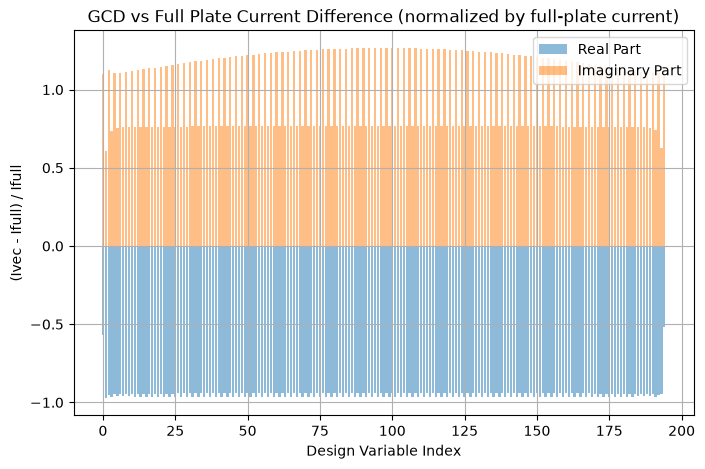

In [ ]:
# A is the total system matrix. Here I'm checking the minimum eigenvalue to see how PSD it is.
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimum eigenvalue: {np.min(np.real(eigenvals))}")
 
sVec = QCQP.current_xstar

Ivec = i0 + sVec # optimal current distribution in original coordinates
Popt = -np.real(Ivec.conj().T @ Obj @ Ivec) + 2*np.real(Ivec.conj().T @ obj) + obj0 # optimal objective value
print(f"Optimal objective value: {Popt:.4e} W")

constraintVal = Ivec.conj().T @ (Ztot @ Ivec - Vinc)
print(f"constraint value in original coordinates: {constraintVal}")
 
 
# normalized by the full-plate current at each design variable.
current_diff_normalized = (Ivec - Ifull) / Ifull

vec_diff = np.linalg.norm(Ivec - Ifull) / np.linalg.norm(Ifull)
print(f"GCD vs full-plate current difference: {vec_diff}")


import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(current_diff_normalized), alpha=0.5, label='Real Part')
plt.bar(np.arange(Ndes), np.imag(current_diff_normalized), alpha=0.5, label='Imaginary Part')
plt.xlabel('Design Variable Index')
plt.ylabel('(Ivec - Ifull) / Ifull')
plt.title('GCD vs Full Plate Current Difference (normalized by full-plate current)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from dolphindes.cvxopt.gcd import GCDHyperparameters
import copy
gcd_QCQP = copy.deepcopy(QCQP)

t = time.time()
opt_params = OptimizationHyperparameters(
    opttol=1e-6,                  
    gradConverge=False,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=0            
)

gcd_params = GCDHyperparameters(
    gcd_tol=1e-6,                 # Keep extremely tight to prevent early exit
    max_proj_cstrt_num=40,       # CRITICAL: > 390. Safely covers all complex degrees of freedom!
    max_gcd_iter_num=40,         # Increased to give GCD enough runway to generate up to 400 constraints
    gcd_iter_period=5,            # Check for convergence every 2*Nopt iterations to give GCD enough time to generate constraints and converge
    orthonormalize=True,
    opt_params=opt_params
)
gcd_QCQP.run_gcd(gcd_params=gcd_params)
print(f'gcd optimization took time {time.time()-t}.')

Precomputed 2 A matrices and Fs vectors.
At GCD iteration #1, best dual bound found is             0.06141710986290644.
At GCD iteration #2, best dual bound found is             0.06131938953615193.
At GCD iteration #3, best dual bound found is             0.06131768494587422.
At GCD iteration #4, best dual bound found is             0.061317680111260056.
At GCD iteration #5, best dual bound found is             0.06131768001995673.
At GCD iteration #6, best dual bound found is             0.06131767993603057.
At GCD iteration #7, best dual bound found is             0.061317679861696076.
At GCD iteration #8, best dual bound found is             0.06131767980333637.
At GCD iteration #9, best dual bound found is             0.06131767974622117.
At GCD iteration #10, best dual bound found is             0.06131767969026845.
gcd optimization took time 1.4435548782348633.


In [ ]:
# Now let's check again for PSD of A. We don't expect the constraints to hold or to have strong duality
lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimal eigenvalue: {np.min(np.real(eigenvals))}")

minimal eigenvalue: 9.90059747429327e-06


bound: 0.06131767898064919, time: 0.083648681640625s
min eigenvalue: 7.4236636936066205e-06
GCD primary objective: 0.06129443881014188
GCD dual bound: 0.06131767898064919
Objective with GCD solution: 0.06129443881014186


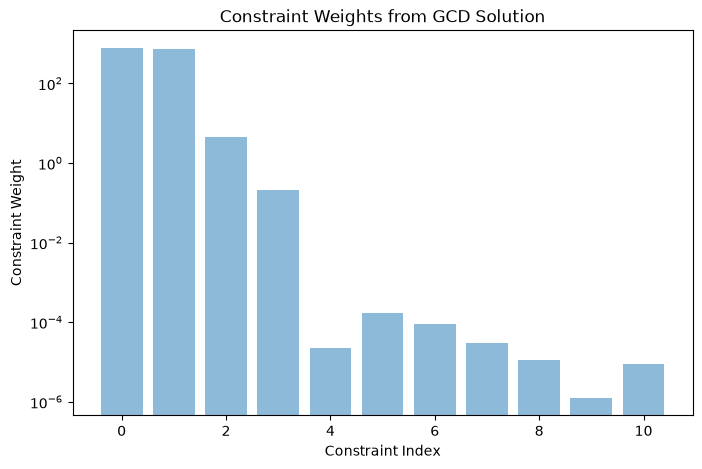

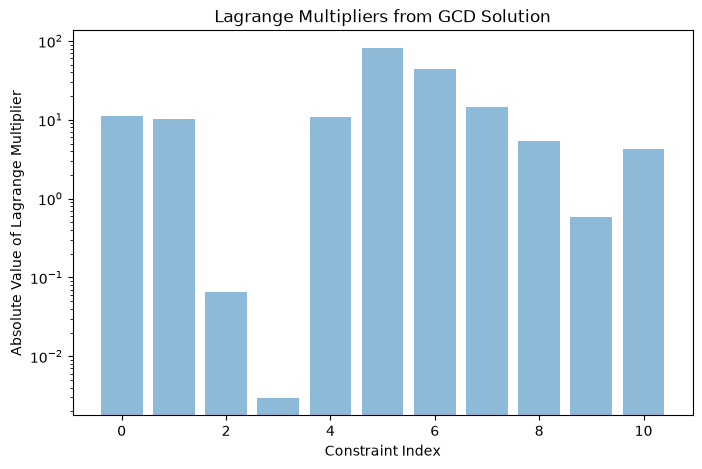

In [ ]:
# Now I take the solved gcd_QCQP and finetune it with BFGS if necessary.
t1 = time.time()
gcd_final_result = gcd_QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = gcd_QCQP.current_lags, opt_params = None)
print(f"bound: {gcd_final_result[0]}, time: {time.time()-t1}s")

# Let's check for PSD-ness and constraints again

lags = gcd_QCQP.current_lags
col_norm = np.zeros(lags.shape[0])
# scale each column of Pdiags by corresponding element in lags
for i in range(lags.shape[0]):
    col_norm[i] = np.linalg.norm(gcd_QCQP.Proj[i].diagonal() * lags[i], ord=2)

totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"min eigenvalue: {np.min(np.real(eigenvals))}")

sVec = gcd_QCQP.current_xstar

primar_obj = -np.real(sVec.conj().T @ Bmat @ sVec) + 2*np.real(sVec.conj().T @ bVec) + beta
print(f"GCD primary objective: {primar_obj}")
print(f"GCD dual bound: {gcd_QCQP.current_dual}")

Ivec = sVec + i0 # optimal current distribution in original coordinates
Porg = -np.real(Ivec.conj().T @ Obj @ Ivec)
print(f"Objective with GCD solution: {Porg}")

plt.figure(figsize=(8, 5))
plt.bar(np.arange(len(lags)), col_norm, alpha=0.5)
plt.xlabel('Constraint Index')
plt.ylabel('Constraint Weight')
plt.title('Constraint Weights from GCD Solution')
plt.yscale('log')
plt.show()

# plot logscale abs(lags)
plt.figure(figsize=(8, 5))
plt.bar(np.arange(len(lags)), np.abs(lags), alpha=0.5)
plt.xlabel('Constraint Index')
plt.ylabel('Absolute Value of Lagrange Multiplier')
plt.title('Lagrange Multipliers from GCD Solution')
plt.yscale('log')
plt.show()  


GCD vs full-plate current difference: 1.390577933917623


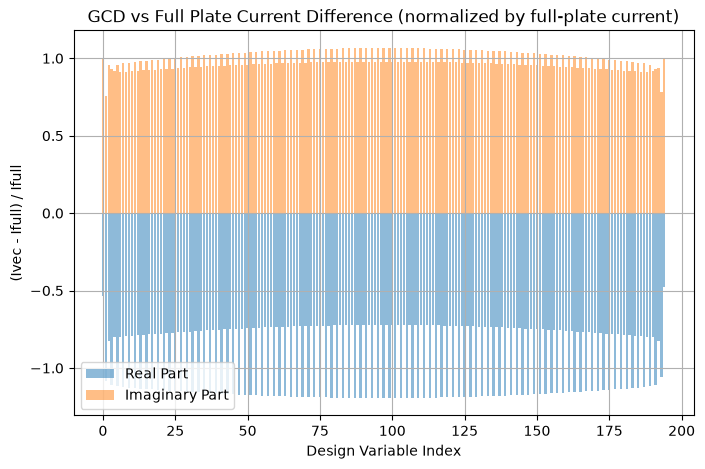

In [ ]:
# Elementwise difference between the GCD current and the full-plate current,
# normalized by the full-plate current at each design variable.
current_diff_normalized = (Ivec - Ifull) / Ifull

vec_diff = np.linalg.norm(Ivec - Ifull) / np.linalg.norm(Ifull)
print(f"GCD vs full-plate current difference: {vec_diff}")

plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(current_diff_normalized), alpha=0.5, label='Real Part')
plt.bar(np.arange(Ndes), np.imag(current_diff_normalized), alpha=0.5, label='Imaginary Part')
plt.xlabel('Design Variable Index')
plt.ylabel('(Ivec - Ifull) / Ifull')
plt.title('GCD vs Full Plate Current Difference (normalized by full-plate current)')
plt.legend()
plt.grid(True)
plt.show()

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
inference error: 1.9790233089095004


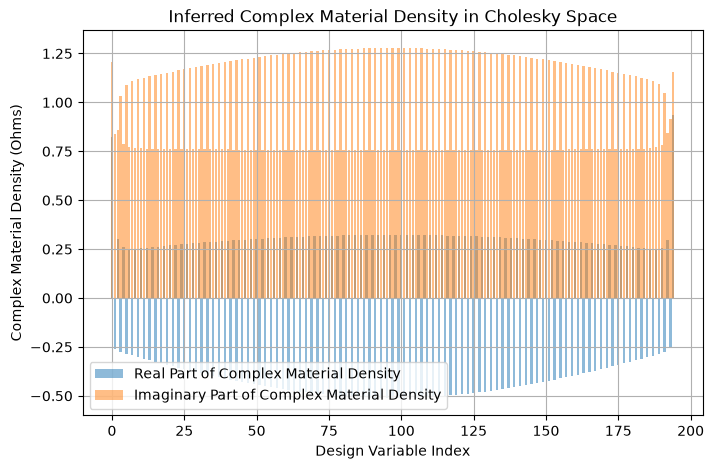

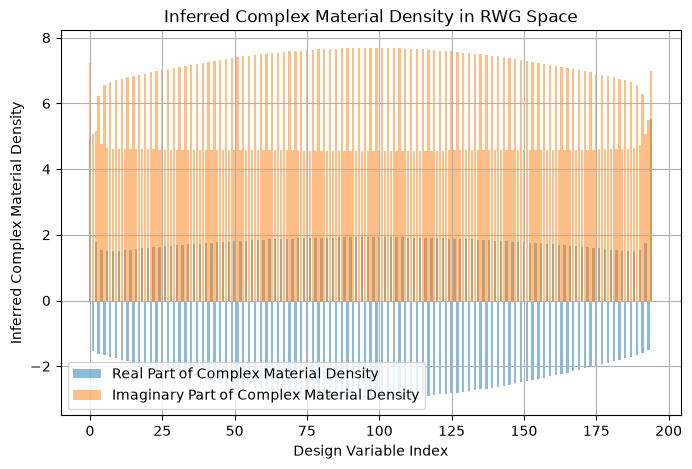

Objective for inferred material density: 1.62650303e+00 W


In [ ]:
Vopt = Z0 @ Ivec
Vinf = Vinc - Vopt
Zinff = Vinf / Ivec

print(f"Surface impedance: {Zs} Ω")

complexMaterialDensityChol = Zs / Zinff
print(f"inference error: {np.max(np.abs(complexMaterialDensityChol - 1))}")

# bar plot with real and imaginary parts of Zinf for Ndes design variables
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensityChol), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensityChol), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Complex Material Density (Ohms)')
plt.title('Inferred Complex Material Density in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()


Zinf = Lchol.conj().T @ np.diag(Zinff) @ Lchol
diagZinf = np.diag(Zinf)
diagZmat = np.diag(Zmat)


complexMaterialDensity = diagZmat / diagZinf

plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensity), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensity), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Inferred Complex Material Density')
plt.title('Inferred Complex Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

# evaluate performmance for inferred material density
ZtotInf = Z0 + Zinf
IfullInf = np.linalg.solve(ZtotInf, Vinc) # current distribution for inferred material density
PfullInf = -np.real(IfullInf.conj().T @ Obj @ IfullInf) # radiated power for inferred material density
print(f"Objective for inferred material density: {PfullInf:.8e} W")


In [ ]:
# Clip unphysical (negative-resistance) entries of the inferred density to a passive
# range and recompute the achievable objective with that clipped material.
n_negative = int((np.real(complexMaterialDensity) < 0).sum())
print(f"Negative (unphysical) entries clipped: {n_negative} / {Ndes}")

material_density_clipped = np.clip(np.real(complexMaterialDensity), 0, 1)

SigmaClipped = np.diag(material_density_clipped)
T = np.eye(Ndes) + SigmaClipped @ Z0
IfullClipped = np.linalg.solve(T, SigmaClipped @ Vinc) # current distribution for clipped material density
PfullClipped = -np.real(IfullClipped.conj().T @ Obj @ IfullClipped) # radiated power for clipped material density
print(f"Objective with clipped material density: {PfullClipped:.6e} W")

Negative (unphysical) entries clipped: 97 / 195
Objective with clipped material density: 7.134312e-06 W


Fitted density: min=0, max=1.768e-18, mean=9.067e-21, median=0
nfev=2352, njev=12


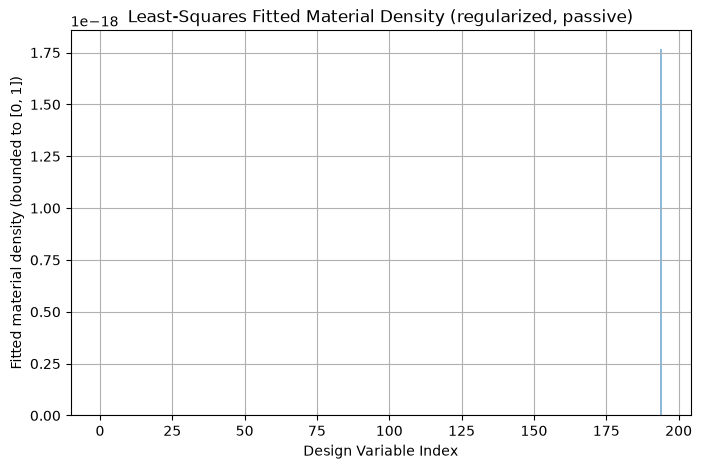

Objective with least-squares fitted material density: 8.573568e-42 W


In [ ]:
# inference from background material
from scipy.optimize import minimize


def _residual(rho):
    Sigma = 1/Zs * np.diag(rho)
    T = np.eye(Ndes) + Sigma @ Z0
    jVec = Sigma @ Vinc - T @ Ifull
    r = T @ sVec - jVec
    return np.linalg.norm(r / np.linalg.norm(jVec),ord=1)



# rho0 = np.full(Ndes, 0.9)
rho0 = material_density_clipped
ls_result = minimize(_residual, rho0, bounds=[(0, 1.0)],
                           tol=1e-15, method='L-BFGS-B')
density_fit = ls_result.x
# print(f"Least-squares fit: normalized residual = {np.sqrt(2 * ls_result.cost):.4e} "
#       "(0 would mean Ivec is exactly realizable by some passive density)")
print(f"Fitted density: min={density_fit.min():.4g}, max={density_fit.max():.4g}, "
      f"mean={density_fit.mean():.4g}, median={np.median(density_fit):.4g}")
print(f"nfev={ls_result.nfev}, njev={ls_result.njev}")

plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), density_fit, alpha=0.5)
plt.xlabel('Design Variable Index')
plt.ylabel('Fitted material density (bounded to [0, 1])')
plt.title('Least-Squares Fitted Material Density (regularized, passive)')
plt.grid(True)
plt.show()

Sigma = 1/Zs * np.diag(density_fit)
T = np.eye(Ndes) + Sigma @ Z0
IfullFit = np.linalg.solve(T, Sigma @ Vinc) # current distribution for the fitted material design
PfullFit = -np.real(IfullFit.conj().T @ Obj @ IfullFit) # radiated power for the fitted material design
print(f"Objective with least-squares fitted material density: {PfullFit:.6e} W")

Fitted density: min=1, max=1, mean=1, median=1
nfev=196, njev=1


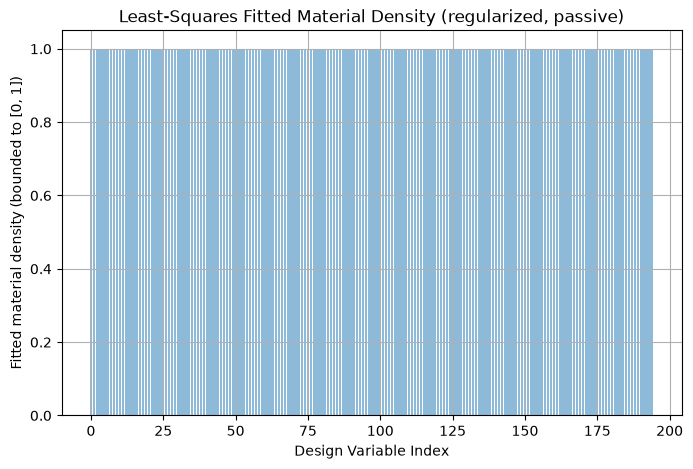

Objective with least-squares fitted material density: 6.095369e-02 W


In [ ]:
# inference


def _residual(rho):
    Sigma = 1/Zs * np.diag(rho)
    T = np.eye(Ndes) + Sigma @ Z0
    jVec = Sigma @ Vinc
    r = T @ Ivec - jVec
    return np.linalg.norm(r / np.linalg.norm(jVec),ord=1)



rho0 = np.full(Ndes, 1)
# rho0 = material_density_clipped
ls_result = minimize(_residual, rho0, bounds=[(0, 1.0)],
                           tol=1e-15, method='L-BFGS-B')
density_fit = ls_result.x
# print(f"Least-squares fit: normalized residual = {np.sqrt(2 * ls_result.cost):.4e} "
#       "(0 would mean Ivec is exactly realizable by some passive density)")
print(f"Fitted density: min={density_fit.min():.4g}, max={density_fit.max():.4g}, "
      f"mean={density_fit.mean():.4g}, median={np.median(density_fit):.4g}")
print(f"nfev={ls_result.nfev}, njev={ls_result.njev}")

plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), density_fit, alpha=0.5)
plt.xlabel('Design Variable Index')
plt.ylabel('Fitted material density (bounded to [0, 1])')
plt.title('Least-Squares Fitted Material Density (regularized, passive)')
plt.grid(True)
plt.show()

Sigma = 1/Zs * np.diag(density_fit)
T = np.eye(Ndes) + Sigma @ Z0
IfullFit = np.linalg.solve(T, Sigma @ Vinc) # current distribution for the fitted material design
PfullFit = -np.real(IfullFit.conj().T @ Obj @ IfullFit) # radiated power for the fitted material design
print(f"Objective with least-squares fitted material density: {PfullFit:.6e} W")

Fitted density: min=1, max=1, mean=1, median=1
nfev=196, njev=1


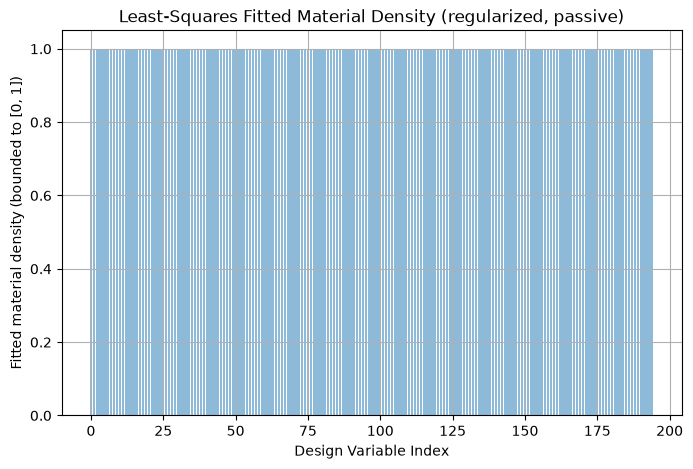

Objective with least-squares fitted material density: 6.095369e-02 W


In [ ]:
# inference


def _residual(rho):
    Zinf = Zs * np.diag(1/rho)
    Zmat = Zinf + Z0
    r = Zmat @ Ivec - Vinc
    return np.linalg.norm(r / np.linalg.norm(Vinc),ord=1)



rho0 = np.full(Ndes, 1)
ls_result = minimize(_residual, rho0, bounds=[(1e-14, 1.0)],
                           tol=1e-15, method='L-BFGS-B')
density_fit = ls_result.x
# print(f"Least-squares fit: normalized residual = {np.sqrt(2 * ls_result.cost):.4e} "
#       "(0 would mean Ivec is exactly realizable by some passive density)")
print(f"Fitted density: min={density_fit.min():.4g}, max={density_fit.max():.4g}, "
      f"mean={density_fit.mean():.4g}, median={np.median(density_fit):.4g}")
print(f"nfev={ls_result.nfev}, njev={ls_result.njev}")

plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), density_fit, alpha=0.5)
plt.xlabel('Design Variable Index')
plt.ylabel('Fitted material density (bounded to [0, 1])')
plt.title('Least-Squares Fitted Material Density (regularized, passive)')
plt.grid(True)
plt.show()

Sigma = 1/Zs * np.diag(density_fit)
T = np.eye(Ndes) + Sigma @ Z0
IfullFit = np.linalg.solve(T, Sigma @ Vinc) # current distribution for the fitted material design
PfullFit = -np.real(IfullFit.conj().T @ Obj @ IfullFit) # radiated power for the fitted material design
print(f"Objective with least-squares fitted material density: {PfullFit:.6e} W")